# RNN vs LSTM for Text Classification

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

In [3]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [4]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load and Explore Data

In [6]:
path = './dataset/Combined Data.csv'
df = pd.read_csv(path)
print('=' * 60)
print('Dataset Overview'.upper())
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

DATASET OVERVIEW
Shape: (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [7]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [10]:
df.shape

(52681, 3)

In [11]:
# Text analysis
df['text_length'] = df['statement'].apply(lambda x: len(x))
df['word_count'] = df['statement'].apply(lambda x: len(x.split()))
df[['text_length', 'word_count']].describe()

,text_length,word_count
count,52681.000000,52681.000000
mean,578.713863,113.158729
std,846.269078,163.735305
min,2.000000,1.000000
25%,80.000000,15.000000
50%,317.000000,62.000000
75%,752.000000,148.000000
max,32759.000000,6300.000000


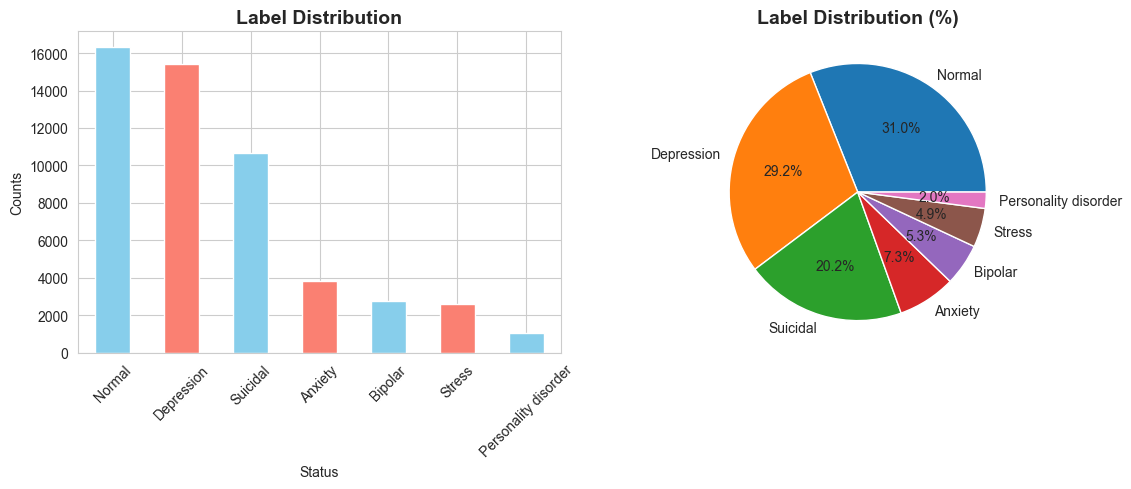

In [12]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
df['status'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Counts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(df['status'].value_counts().values, labels=df['status'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Label Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()


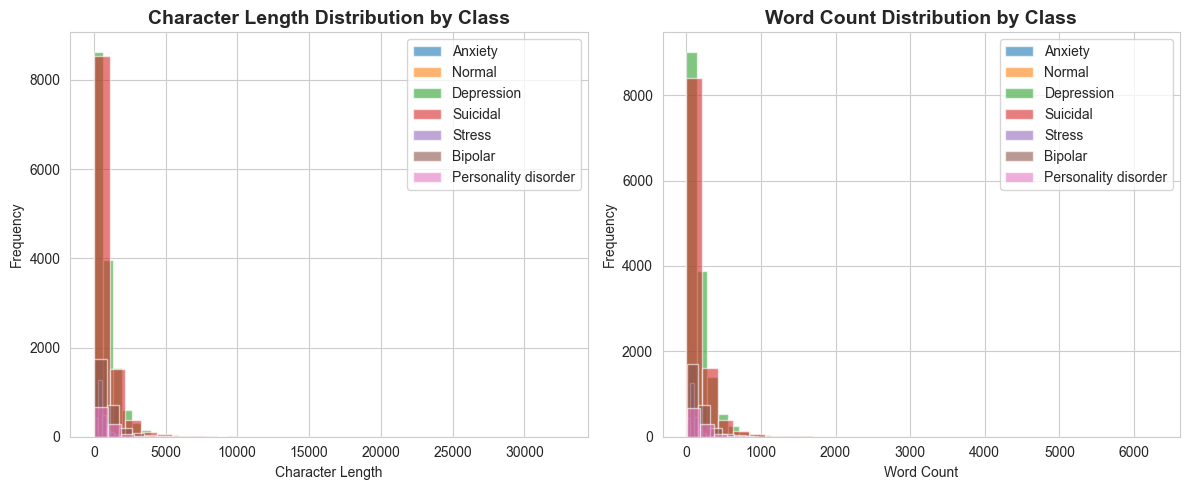

In [20]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Character length
for label in df['status'].unique():
    subset = df[df['status'] == label]['text_length']
    axes[0].hist(subset, alpha=0.6, label=label, bins=30)
axes[0].set_title('Character Length Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count
for label in df['status'].unique():
    subset = df[df['status'] == label]['word_count']
    axes[1].hist(subset, alpha=0.6, label=label, bins=30)
axes[1].set_title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()

In [29]:
# Sample texts from each class
print('=' * 60)
print('SAMPLE TEXTS FROM EACH CLASS')
print('=' * 60)
for label in df['status'].unique():
    print(f'\n---{label.upper()}---')
    samples = df[df['status'] == label]['statement'].head(1).tolist()
    print(samples)

SAMPLE TEXTS FROM EACH CLASS

---ANXIETY---
['oh my gosh']

---NORMAL---
['Gr gr dreaming of ex crush to be my game, God']

---DEPRESSION---
['I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about things it always hurts. I just want to lose feelings so all this pain can stop it hurts so much and I cannot even cry about it. I do not want to hurt her because she said she does not want to never speak to me again but I do not know what to do here. When we were together she always hurt me so I do not know why I still love her. I wish we never met it would be much less painful How do I lose feelings?']

---SUICIDAL---
["I am so exhausted of this. Just when I think I can finally rest, just when I think maybe things are starting to settle, another hurdle comes flying at me. This month alone we found out my mum could be dying, my girlfriend left me, my parents revealed that they wanted a divorce, my grandad was

## Data Preprocessing

In [43]:
import re
import string

class TextPreprocessor:

    def __init__(self, max_vocab_size=10000, embedding_dim=100, max_seq_length=100):
        self.max_vocab_size = max_vocab_size
        self.embedding_dim = embedding_dim
        self.max_seq_length = max_seq_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
        
    
    def clean_text(self, text):
        text = text.lower()
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove user mentionis and hashhtags
        text = re.sub(r'\@\w+|\#', '', text)
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text


    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            cleaned_text = self.clean_text(text)
            words = cleaned_text.split()
            word_counts.update(words)

        most_common = word_counts.most_common(self.max_vocab_size - 2)
        for word, frequency in most_common:
            if word not in self.word2idx.keys():
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1
        
        print(f"Vocab size: {self.vocab_size}")


    def text_to_sequence(self, text):
        cleaned_text = self.clean_text(text)
        words = cleaned_text.split()
        sequence = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in words]
        if len(sequence) > self.max_seq_length:
            sequence = sequence[:self.max_seq_length]
        
        return sequence
    

    def encode_texts(self, texts):
        return [self.text_to_sequence(text) for text in texts]

In [44]:
preprocessing = TextPreprocessor()
preprocessing.build_vocab(df['statement'].tolist())
preprocessing.encode_texts(df['statement'].tolist())[0]

Vocab size: 10000


[607, 6, 4811]